# A thousand Kepler orbits: symplectic methods keep the energy, RK4 loses it

Over a long simulation of a conservative system, what matters is often less the error at one
time than whether the invariants stay put. A symplectic method's energy error stays bounded
however long it runs, while a Runge-Kutta method's drifts. This notebook integrates 1000 orbits of
the Kepler problem, $10^5$ steps, with Störmer-Verlet, symplectic Euler and RK4 at the same step,
records the energy and the angular momentum once per orbit, and checks the methods' orders
against `solve_ivp`.

| Scaly feature | Where |
| --- | --- |
| `si.symplectic(model, "stormer_verlet" / "symplectic_euler", split=2)` | maps of one orbit |
| `steps=100`: the substeps run as a scan inside the generated C | one call per orbit |
| `dt=None`: the interval an input, one map for every step size | the last orbit, the orders |
| `si.rk4` | the comparison |
| `write_module` | the generated C |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "symplectic_orbits"

## The Kepler problem

A unit mass around a unit attracting mass at the origin, with positions $q = (q_1, q_2)$ and
velocities $v = (v_1, v_2)$, the state $x = (q, v)$:

$$
\dot q = v, \qquad \dot v = -\frac{q}{|q|^3} .
$$

The model is separable: $\dot q$ depends only on $v$, and $\dot v$ only on $q$. It conserves the
energy $H = \tfrac12 |v|^2 - 1/|q|$ and, the force being central, the angular momentum
$L = q_1 v_2 - q_2 v_1$. From the perihelion of an orbit of eccentricity $e = 0.6$,
$q = (1 - e, 0)$, $v = (0, \sqrt{(1 + e)/(1 - e)}) = (0, 2)$, the orbit is an ellipse with
semi-major axis 1 and period $2\pi$, $H = -1/2$ and $L = \sqrt{1 - e^2} = 0.8$.

In [2]:
ECCENTRICITY = 0.6
X0 = np.array([1.0 - ECCENTRICITY, 0.0, 0.0, np.sqrt((1.0 + ECCENTRICITY) / (1.0 - ECCENTRICITY))])
PERIOD = 2.0 * np.pi


@sc.function(4, output="xdot", name="symplectic_orbits_kepler")
def kepler(x):
  q, v = x[:2], x[2:]
  r2 = (q * q).sum()
  return sc.concat([v, -q / (r2 * r2.sqrt())])


def energy(x):
  return 0.5 * (x[..., 2] ** 2 + x[..., 3] ** 2) - 1.0 / np.hypot(x[..., 0], x[..., 1])


def angular_momentum(x):
  return x[..., 0] * x[..., 3] - x[..., 1] * x[..., 2]


h0, l0 = energy(X0), angular_momentum(X0)
print(f"H = {h0:.3f}, L = {l0:.3f}")

H = -0.500, L = 0.800


## Maps of one orbit

`si.symplectic(model, method, split=2, ...)` reads the first `split` entries of the state as
positions and the rest as velocities. With step $h$ and $a(q) = -q/|q|^3$ read from the model,
Störmer-Verlet (order 2) is a half kick, a drift and a half kick,

$$
v_{1/2} = v + \tfrac{h}{2}\, a(q), \qquad q_1 = q + h\, v_{1/2}, \qquad v_1 = v_{1/2} + \tfrac{h}{2}\, a(q_1),
$$

and symplectic Euler (order 1) a kick then a drift, $v_1 = v + h\, a(q)$, $q_1 = q + h\, v_1$.
For a separable model both are symplectic: they preserve phase-space area exactly, which is what
keeps the energy error bounded over long times. For a model that is not separable
`si.symplectic` builds explicit partitioned methods of the same form, which are not symplectic.

Each map below takes 100 steps over an interval `dt` given as an input: the steps run as a
scan in the generated C, and one call with `dt` $= 2\pi$ is one orbit at $h = 2\pi / 100$.

In [3]:
STEPS_PER_ORBIT, ORBITS = 100, 1000  # h = 2 pi / 100, 1e5 steps
MAPS = {
  "stormer_verlet": si.symplectic(kepler, "stormer_verlet", split=2, dt=None, steps=STEPS_PER_ORBIT, name="symplectic_orbits_verlet"),
  "symplectic_euler": si.symplectic(kepler, "symplectic_euler", split=2, dt=None, steps=STEPS_PER_ORBIT, name="symplectic_orbits_euler"),
  "rk4": si.rk4(kepler, dt=None, steps=STEPS_PER_ORBIT, name="symplectic_orbits_rk4"),
}
COLORS = {"stormer_verlet": plotstyle.BLUE, "symplectic_euler": plotstyle.ORANGE, "rk4": plotstyle.AQUA}
for method, step in MAPS.items():
  print(f"{method:<17} {step.name}{step.input_names} -> {step.output_names}")

stormer_verlet    symplectic_orbits_verlet('x', 'dt') -> ('xnext',)
symplectic_euler  symplectic_orbits_euler('x', 'dt') -> ('xnext',)
rk4               symplectic_orbits_rk4('x', 'dt') -> ('xnext',)


## A thousand orbits

Each method runs 1000 orbits, one call each, and the energy and angular momentum are recorded at
the end of every orbit.

In [4]:
states = {}
for method, step in MAPS.items():
  x = [X0]
  for _ in range(ORBITS):
    x.append(step(x[-1], np.array(PERIOD)))
  states[method] = np.array(x)
energy_error = {m: np.abs(energy(x[1:]) - h0) for m, x in states.items()}
momentum_error = {m: np.abs(angular_momentum(x[1:]) - l0) for m, x in states.items()}
tenth = ORBITS // 10
results = {
  m: {
    "energy_first_tenth": energy_error[m][:tenth].max(),
    "energy_last_tenth": energy_error[m][-tenth:].max(),
    "momentum_drift": momentum_error[m].max(),
  }
  for m in MAPS
}
print(f"  {'method':<17} {'|dH| first tenth':>17} {'|dH| last tenth':>16} {'max |dL|':>9}")
for m, r in results.items():
  print(f"  {m:<17} {r['energy_first_tenth']:17.2e} {r['energy_last_tenth']:16.2e} {r['momentum_drift']:9.1e}")

  method             |dH| first tenth  |dH| last tenth  max |dL|
  stormer_verlet             1.49e-02         1.49e-02   2.6e-14
  symplectic_euler           1.29e-01         1.30e-01   1.1e-14
  rk4                        1.06e-02         1.15e-01   2.1e-02


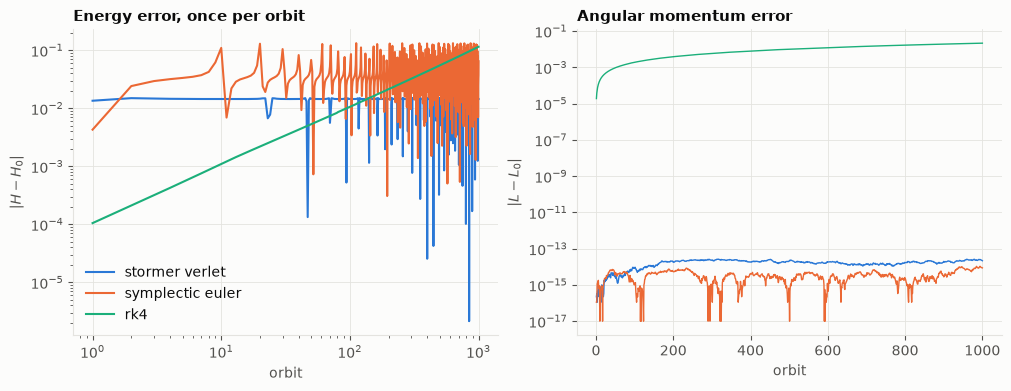

In [5]:
orbit_number = np.arange(1, ORBITS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for m in MAPS:
  ax1.loglog(orbit_number, energy_error[m], color=COLORS[m], lw=1.5, label=m.replace("_", " "))
  ax2.semilogy(orbit_number, np.maximum(momentum_error[m], 1e-17), color=COLORS[m], lw=1, label=m.replace("_", " "))
ax1.set_xlabel("orbit")
ax1.set_ylabel(r"$|H - H_0|$")
ax1.set_title("Energy error, once per orbit")
ax1.legend()
ax2.set_xlabel("orbit")
ax2.set_ylabel(r"$|L - L_0|$")
ax2.set_title("Angular momentum error")
plt.show()

Störmer-Verlet's largest energy error is $1.49 \times 10^{-2}$ in the first hundred orbits and
in the last hundred: bounded. Symplectic Euler's is bounded too, at 0.13, larger for a method of
first order. Both vary from orbit to orbit because the sample falls at a slowly moving phase of
the orbit. RK4's grows in proportion to time, a line of slope 1 on the log-log axes, from
$1.1 \times 10^{-2}$ in the first hundred orbits to 0.115 in the last: being of fourth order it
starts below Störmer-Verlet's and ends eight times above it. Both symplectic methods conserve the
angular momentum to $3 \times 10^{-14}$, since a kick along $q$ and a drift along $v$ each leave
$q \times v$ unchanged; RK4 loses $2.1 \times 10^{-2}$ of 0.8.

## The last orbit

Recorded once per orbit, the energy error is seen at one phase of the orbit only. Within an
orbit it varies: the maps with `steps=100` take `dt` as an input, and
called with `dt` $= 2\pi / 100$ they take 100 substeps of $h / 100$, not one step of $h$, so tracing
the orbit at the step $h$ needs maps of one step each, `steps=1`. From each method's state after
999 orbits, 100 steps of those trace the last orbit.

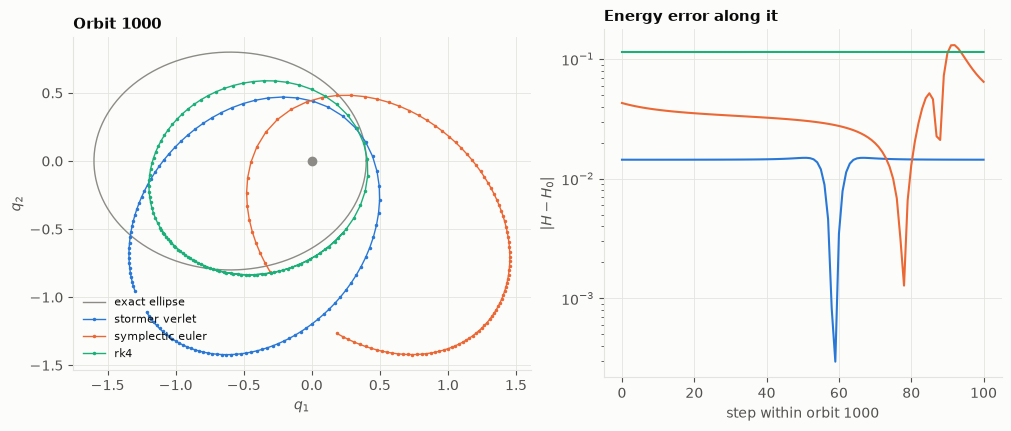

the one-step maps end orbit 1000 within 0.0e+00 of the per-orbit maps
                         a      e     perihelion    |dH| along orbit 1000
  exact              1.000  0.600        0.0 deg
  stormer_verlet     1.030  0.615       47.7 deg     3.0e-04 to 1.5e-02
  symplectic_euler   1.148  0.665      136.0 deg     1.3e-03 to 1.3e-01
  rk4                0.813  0.505       17.4 deg     1.1e-01 to 1.1e-01


In [6]:
ONE_STEP = {
  "stormer_verlet": si.symplectic(kepler, "stormer_verlet", split=2, dt=None, name="symplectic_orbits_verlet_1"),
  "symplectic_euler": si.symplectic(kepler, "symplectic_euler", split=2, dt=None, name="symplectic_orbits_euler_1"),
  "rk4": si.rk4(kepler, dt=None, name="symplectic_orbits_rk4_1"),
}
h = np.array(PERIOD / STEPS_PER_ORBIT)
last_orbit = {}
for m, step in ONE_STEP.items():
  x = [states[m][-2]]
  for _ in range(STEPS_PER_ORBIT):
    x.append(step(x[-1], h))
  last_orbit[m] = np.array(x)
trace_gap = max(np.abs(last_orbit[m][-1] - states[m][-1]).max() for m in MAPS)

theta = np.linspace(0.0, 2 * np.pi, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
ax1.plot(np.cos(theta) - ECCENTRICITY, 0.8 * np.sin(theta), color=plotstyle.NEUTRAL, lw=1, label="exact ellipse")
ax1.plot(0.0, 0.0, "o", color=plotstyle.NEUTRAL, ms=6)
for m in MAPS:
  ax1.plot(last_orbit[m][:, 0], last_orbit[m][:, 1], ".-", color=COLORS[m], lw=1, ms=3, label=m.replace("_", " "))
  ax2.semilogy(np.arange(STEPS_PER_ORBIT + 1), np.abs(energy(last_orbit[m]) - h0), color=COLORS[m], lw=1.5)
ax1.set_aspect("equal")
ax1.set_xlabel("$q_1$")
ax1.set_ylabel("$q_2$")
ax1.set_title("Orbit 1000")
ax1.legend(loc="lower left", fontsize=8)
ax2.set_xlabel("step within orbit 1000")
ax2.set_ylabel(r"$|H - H_0|$")
ax2.set_title("Energy error along it")
plt.show()
print(f"the one-step maps end orbit 1000 within {trace_gap:.1e} of the per-orbit maps")


def elements(x):
  """Semi-major axis, eccentricity and perihelion angle in degrees, from H and the Laplace-Runge-Lenz vector."""
  q, v, momentum = x[:2], x[2:], angular_momentum(x)
  lrl = np.array([v[1] * momentum, -v[0] * momentum]) - q / np.hypot(*q)
  return -0.5 / energy(x), np.hypot(*lrl), np.degrees(np.arctan2(lrl[1], lrl[0]))


print(f"  {'':<17} {'a':>6} {'e':>6} {'perihelion':>14} {'|dH| along orbit 1000':>24}")
print(f"  {'exact':<17} {1.0:6.3f} {ECCENTRICITY:6.3f} {0.0:10.1f} deg")
for m in MAPS:
  axis, ecc, angle = elements(states[m][-1])
  e = np.abs(energy(last_orbit[m]) - h0)
  print(f"  {m:<17} {axis:6.3f} {ecc:6.3f} {angle:10.1f} deg {e.min():11.1e} to {e.max():.1e}")

Along orbit 1000, Störmer-Verlet's energy error is $1.5 \times 10^{-2}$ for most of the orbit and
falls to $3 \times 10^{-4}$ at step 59, the perihelion, where the run started. A symplectic method
conserves a modified energy $\tilde H = H + O(h^2)$ over very long times, so the error in $H$
depends on where the body is on its orbit, not on how long it has flown. The orbit keeps its size
and shape to $O(h^2)$ ($a = 1.030$, $e = 0.615$) but its perihelion has turned by 48°: the
invariants are kept, the phase is not. Symplectic Euler's orbit has turned by 136°, with an energy
error up to 0.13 along it. RK4's error is 0.11 all along the orbit, the energy lost over 999
orbits, which has shrunk the orbit to $a = 0.81$ and $e = 0.51$. The one-step maps reproduce the
per-orbit maps' last state exactly: the scan in the generated C takes the same steps.

## Orders

Over a short interval $[0, 1]$ from the perihelion, through the fastest part of the orbit, the
error against `solve_ivp` (DOP853 at $10^{-13}$) should fall as $h^p$: $p = 2$ for Störmer-Verlet,
1 for symplectic Euler and 4 for RK4. The same per-orbit maps serve: $k$ calls with `dt` $= 1/k$
take $100 k$ steps of $h = 1 / (100 k)$.

  method               h = 0.01   h = 0.005  h = 0.0025 h = 0.00125  order
  stormer_verlet       8.51e-04    2.13e-04    5.32e-05    1.33e-05   2.00
  symplectic_euler     2.94e-02    1.51e-02    7.62e-03    3.83e-03   0.97
  rk4                  1.29e-07    7.83e-09    4.81e-10    3.00e-11   4.05


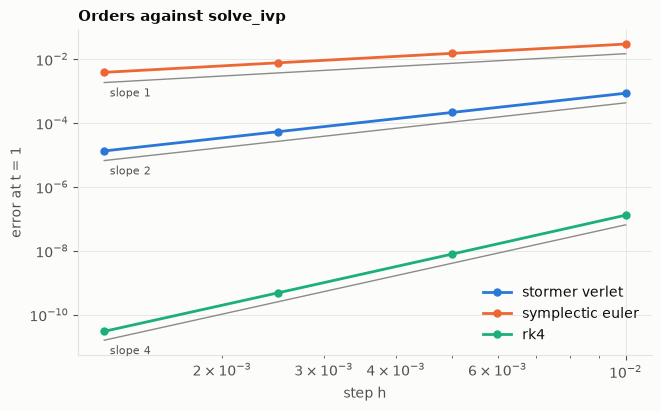

In [7]:
SHORT, CALLS = 1.0, (1, 2, 4, 8)
exact = solve_ivp(lambda t, x: [x[2], x[3], *(-x[:2] / np.hypot(x[0], x[1]) ** 3)], (0.0, SHORT), X0, method="DOP853", rtol=1e-13, atol=1e-13).y[
  :, -1
]
short_errors = {}
for m, step in MAPS.items():
  short_errors[m] = []
  for calls in CALLS:
    x = X0
    for _ in range(calls):
      x = step(x, np.array(SHORT / calls))
    short_errors[m].append(np.abs(x - exact).max())
  results[m]["short_errors"] = short_errors[m][:2]
  results[m]["order"] = np.log2(short_errors[m][0] / short_errors[m][1])
hs = SHORT / (STEPS_PER_ORBIT * np.array(CALLS))
print(f"  {'method':<17}" + "".join(f"{f'h = {h_:g}':>12}" for h_ in hs) + f"{'order':>7}")
for m in MAPS:
  print(f"  {m:<17}" + "".join(f"{e:12.2e}" for e in short_errors[m]) + f"{results[m]['order']:7.2f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
for m, p in (("stormer_verlet", 2), ("symplectic_euler", 1), ("rk4", 4)):
  ax.loglog(hs, short_errors[m], "o-", color=COLORS[m], label=m.replace("_", " "))
  ax.loglog(hs, 0.5 * short_errors[m][0] * (hs / hs[0]) ** p, color=plotstyle.NEUTRAL, lw=1)
  ax.annotate(
    f"slope {p}",
    (hs[-1], 0.5 * short_errors[m][0] * (hs[-1] / hs[0]) ** p),
    xytext=(4, -10),
    textcoords="offset points",
    color=plotstyle.TEXT_SECONDARY,
    fontsize=8,
  )
ax.set_xlabel("step h")
ax.set_ylabel("error at t = 1")
ax.set_title("Orders against solve_ivp")
ax.legend()
plt.show()

The observed orders are 2.00, 0.97 and 4.05. Each halving of $h$ divides Störmer-Verlet's error by
4.0 and RK4's by 16, down to $3.0 \times 10^{-11}$ at $h = 0.00125$. Symplectic Euler, first order,
is the least accurate here and in the long run; its virtue is only the bounded energy it shares
with Störmer-Verlet.

## Checks

The numbers above, held to tolerances with a margin of about ten over what was measured.

In [8]:
checks = 0
assert abs(h0 + 0.5) < 1e-12 and abs(l0 - 0.8) < 1e-12
checks += 1
for method in ("stormer_verlet", "symplectic_euler"):
  r = results[method]
  assert 0.9 < r["energy_last_tenth"] / r["energy_first_tenth"] < 1.1  # bounded: no drift over 1000 orbits
  assert r["momentum_drift"] < 1e-12  # a central force: angular momentum to rounding
  checks += 2
verlet, euler, rk4 = results["stormer_verlet"], results["symplectic_euler"], results["rk4"]
assert verlet["energy_last_tenth"] < 0.05 and euler["energy_last_tenth"] < 0.5
assert rk4["energy_last_tenth"] / rk4["energy_first_tenth"] > 5 and rk4["energy_last_tenth"] > 3 * verlet["energy_last_tenth"]
assert rk4["momentum_drift"] > 1e-3
assert abs(verlet["order"] - 2) < 0.1 and abs(euler["order"] - 1) < 0.1 and abs(rk4["order"] - 4) < 0.2
checks += 4
print(f"{checks} checks passed")

9 checks passed


## The generated C

The Störmer-Verlet map is a loop of 100 calls of one substep kernel, ping-ponging the state
between two buffers. The half step $h/2$ does not change inside the loop and is computed once
before it. Each substep evaluates the force twice, at the old and at the new position (`v5` and
`v11`); the model call for the drift reduces to $q + h\, v_{1/2}$.

In [9]:
module = write_module(MAPS["stormer_verlet"], GENERATED)
print(
  f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.1f} kB, in {GENERATED.relative_to(Path.cwd().parent.parent)}"
)
lines = module.source.splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("static inline void symplectic_orbits_verlet_substep_hoisted"))
end = lines.index("}", next(i for i, line in enumerate(lines) if line.startswith("int symplectic_orbits_verlet(")))
print("\n".join(line for line in lines[start : end + 1] if line.strip()))

symplectic_orbits_verlet.c: 70 lines, 2.1 kB, in examples/generated/integrators/symplectic_orbits
static inline void symplectic_orbits_verlet_substep_hoisted_1_raw(const double* x, const double* h, const double* t3, double* xnext, double* w) {
  (void)w;
  double v0 = x[0];
  double v1 = h[0];
  double v2 = t3[0];
  double v3 = x[1];
  double v4 = ((v0 * v0) + (v3 * v3));
  double v5 = (v4 * sqrt(v4));
  double v6 = (x[2] - (v2 * (v0 / v5)));
  double v7 = (v0 + (v1 * v6));
  double v8 = (x[3] - (v2 * (v3 / v5)));
  double v9 = (v3 + (v1 * v8));
  double v10 = ((v7 * v7) + (v9 * v9));
  double v11 = (v10 * sqrt(v10));
  *(double2*)(xnext) = (double2){v7, v9};
  *(double2*)(xnext + 2) = (double2){(v6 - (v2 * (v7 / v11))), (v8 - (v2 * (v9 / v11)))};
}
int symplectic_orbits_verlet(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) retu